# *A. niger* Infection — Green → Mature → Post-harvest Trajectory

**Phase 4:** A single continuous dFBA simulation tracing *A. niger* infection across the full developmental trajectory of a *V. vinifera* berry:

| Phase | Duration | Berry state | Leakage |
|---|---|---|---|
| **Green** | $2$ days ($48h$) | Pre-véraison, thick cell wall | $20\%$ of proxy |
| **Mature** | $4$ days ($96h$) | Post-véraison, softened cell wall | $100\%$ of proxy |
| **Post-harvest** | $12$ days ($288h$) | Detached, sucrose depleting | $100\%$ of proxy |

**Total simulation:** $18$ days ($432h$)

---
* **Author:** Joana Maia
* **Solver:** Gurobi (Academic Licence)
* **Core libraries:** COBRApy · Pandas · Seaborn · Matplotlib
* **Models:** *iMS7199* (*V. vinifera* green) × *iJB1325* (*Aspergillus niger*) · *iMS7199* (*V. vinifera* mature) × *iJB1325* (*Aspergillus niger*) 

---
**Biological rationale for leakage factors:**
- **Green ($20\%$):** Pre-véraison cell wall is thick and lignified — *A. niger* hyphae penetrate with difficulty; cytoplasmic access is severely limited. The $20\%$ factor reflects partial but non-negligible early colonisation.
- **Mature ($100\%$):** Véraison softens the cell wall via polygalacturonase and pectin-methylesterase activity; full cytoplasmic exposure assumed.
- **Post-harvest ($100\%$):** Cell wall integrity is irreversibly lost after detachment; leakage remains at maximum. Sucrose depletion is modelled explicitly via a Michaelis–Menten resource factor, reducing glucose/fructose T1 flux as the reserve depletes.

**Note:** Leakage factors ($20\%$, $100\%$, $100\%$) are phenomenological parameters based on qualitative cell wall permeability assumptions — not derived from experimental membrane permeability data. The post-harvest phase is extended to $12$ days ($288h$) to capture the full sucrose depletion trajectory and fungal biomass collapse.

**Phase durations** are simulation-tractable approximations of biological timescales (*véraison* ~$50–60$ days post-flowering; harvest ~$100–120$ days post-flowering; post-harvest storage ~$10–14$ days).

## 1. Environment Setup
### 1.1 Package Installation

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn

### 1.2 Library Imports and Version Audit

In [2]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra import Model, Reaction, Metabolite
from cobra.flux_analysis import (pfba)
from cobra.io import read_sbml_model
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


### 1.3 Global Plotting Style

In [3]:
sns.set_theme(style = 'whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams.update({'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False})

C_GREEN    = '#2D6A4F'   # green phase
C_MATURE   = '#70AD47'   # mature phase
C_HARVEST  = '#E76F51'   # post-harvest phase
C_FUNGUS   = '#8367C7'   # A. niger
C_INF      = '#FF8A8A'   # infection
C_VERAISON = '#FFB703'   # véraison transition
C_HARVEST2 = '#E63946'   # harvest transition

### 1.4 Model Loading

Loads the curated models from Phase 1A (`An_curated.xml`, *iJB1325*), Phase 1B (`VvM_mature_curated.xml`, *iMS7199*) and Phase 1C (`VvG_green_curated.xml`, *iMS7199*)

In [4]:
vv_green  = read_sbml_model('VvG_green_curated.xml')
vv_mature = read_sbml_model('VvM_mature_curated.xml')
an_raw    = read_sbml_model('An_curated.xml')

mu_green  = vv_green.optimize().objective_value
mu_mature = vv_mature.optimize().objective_value

print(f'V. vinifera green  : μ = {mu_green:.4f} h⁻¹')
print(f'V. vinifera mature : μ = {mu_mature:.4f} h⁻¹')
print(f'A. niger           : μ = {an_raw.optimize().objective_value:.4f} h⁻¹')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt


'' is not a valid SBML 'SId'.


V. vinifera green  : μ = 0.1446 h⁻¹
V. vinifera mature : μ = 0.1541 h⁻¹
A. niger           : μ = 0.9399 h⁻¹


## 2. Parameters

All model parameters are defined here. Three groups:

**Leakage factors** — fraction of the cytoplasmic flux proxy transferred via T1 per phase. Reflect cell wall permeability at each developmental stage.

**Phase durations** — simulation time windows for each berry stage. Post-harvest is extended to $288h$ to capture the full sucrose depletion and biomass collapse trajectory.

**Sucrose dynamics** — the sucrose reserve is tracked explicitly as a state variable. Inflow (`SUCROSE_INFLOW`) represents phloem loading; berry consumption (`SUCROSE_BERRY_USE`) is held constant across phases at $0.3\ \text{mmol/L/h}$. This is a simplifying assumption: post-harvest tissue has lower respiratory activity than actively ripening berry, and a biologically accurate model would use a reduced value for that phase. However, calibration data for *in vivo* post-harvest sucrose consumption by *V. vinifera* tissue are not available here. The uniform value is conservative — it accelerates sucrose depletion in post-harvest, producing a faster biomass collapse consistent with the trajectory in Fig. 1. Post-harvest inflow = $0$. Glucose/fructose T1 flux is scaled by a Michaelis–Menten factor $mm_{suc} = c_{suc} / (c_{suc} + K_M)$, coupling fungal sugar uptake to berry sucrose availability.

**Death rates** — phase-specific first-order fungal death rates ($\delta$, h⁻¹$). These parameters are **phenomenological**: no direct experimental measurements of *A. niger* death rates *in vivo* in *V. vinifera* berry tissue are available in the literature. Values were chosen to reproduce the qualitative infection timeline observed in field and chamber studies, not calibrated against quantitative data.

| Phase | $\delta$ h⁻¹ | Half-life | Biological rationale |
|---|---|---|---|
| Green | $0.003$ | $\approx 231\ h$ | Hostile environment; stilbene defences active; slow fungal establishment |
| Mature | $0.002$ | $\approx 347\ h$ | Permissive post-véraison conditions; growth dominates over death |
| Post-harvest | $0.050$ | $\approx 14\ h$ | **Critical parameter.** Drives biomass collapse after sucrose exhaustion. Represents accelerated autolysis in nutrient-depleted, desiccating tissue. This value has the largest effect on the post-harvest trajectory shape and carries the highest uncertainty. See `3C_sensitivity.ipynb` for the general robustness framework. |

In [5]:
GAS_NAMES = {'O2', 'CO2', 'Water'}

LEAK_GREEN       = 0.20 # 20%  — thick cell wall, partial early colonisation
LEAK_MATURE      = 1.00 # 100% — softened cell wall post-véraison
LEAK_POSTHARVEST = 1.00 # 100% — cell wall integrity lost; sucrose depletion via MM

T_GREEN       = 48.0    # hours — 2 days green
T_MATURE      = 96.0    # hours — 4 days mature
T_POSTHARVEST = 288.0   # hours — 8 days post-harvest
T_TOTAL       = T_GREEN + T_MATURE + T_POSTHARVEST  # 432h

T_VERAISON  = T_GREEN               # 48h
T_HARVEST_T = T_GREEN + T_MATURE    # 144h

SUCROSE_INIT = 150.0  # mmol/L — reserva background green
SUCROSE_MAX  = 300.0  # mmol/L — cap mature
KM_SUC       = 10.0   # mmol/L

# Green: inflow = berry_use → delta ≈ 0 → sucrose fixed
# Mature: inflow >> berry_use → accumulates
# Post-harvest: inflow = 0 → depletes
SUCROSE_INFLOW = {'green'      : 0.3,    # balances berry_use → sucrose fixed
                  'mature'     : 3.0,    # active phloem — strong accumulation
                  'postharvest': 0.0,}   # no phloem

SUCROSE_BERRY_USE = {'green'      : 0.3,    # same as inflow → delta ≈ 0
                     'mature'     : 0.3,    # post-mitotic
                     'postharvest': 0.3,}   # maintenance + respiration


DEATH_RATE = {'green'      : 0.003,
              'mature'     : 0.002,
              'postharvest': 0.05,} # low — decline driven by K_effective


print(f'Total simulation : {T_TOTAL:.0f}h ({T_TOTAL/24:.0f} days)')
print(f'Véraison at      : t = {T_VERAISON:.0f}h | Harvest at: t = {T_HARVEST_T:.0f}h')
print(f'Leakage          : Green = {LEAK_GREEN:.0%} | Mature = {LEAK_MATURE:.0%} | Post-harvest = {LEAK_POSTHARVEST:.0%}')
print(f'Death rates      : {DEATH_RATE}')

Total simulation : 432h (18 days)
Véraison at      : t = 48h | Harvest at: t = 144h
Leakage          : Green = 20% | Mature = 100% | Post-harvest = 100%
Death rates      : {'green': 0.003, 'mature': 0.002, 'postharvest': 0.05}


In [ ]:
INTERFACE_EXACT = {
    'Glucose'  :{'vv_id':'GLC__cyto',            'an_id':'GLCe'},
    'Fructose' :{'vv_id':'Fructofuranose__cyto',  'an_id':'FRUe'},
    'Malate'   :{'vv_id':'MAL__cyto',             'an_id':'MALe'},
    'Fumarate' :{'vv_id':'FUM__cyto',             'an_id':'FUMe'},
    'Citrate'  :{'vv_id':'CIT__cyto',             'an_id':'CITe'},
    'Succinate':{'vv_id':'SUC__cyto',             'an_id':'SUCCe'},
    'Proline'  :{'vv_id':'PRO__cyto',             'an_id':'PROe'},
    'Leucine'  :{'vv_id':'LEU__cyto',             'an_id':'LEUe'},
    'Serine'   :{'vv_id':'SER__cyto',             'an_id':'SERe'},
    'Glutamate':{'vv_id':'GLT__cyto',             'an_id':'GLUe'},
    'Alanine'  :{'vv_id':'L-ALPHA-ALANINE__cyto', 'an_id':'ALAe'},
    'Glycine'  :{'vv_id':'GLY__cyto',             'an_id':'GLYe'},
    'Nitrate'  :{'vv_id':'NITRATE__cyto',         'an_id':'HNO3e'},
    'Phosphate':{'vv_id':'Pi__cyto',              'an_id':'PIe'},
    'Sulfate'  :{'vv_id':'SULFATE__cyto',         'an_id':'SLFe'},
    'Adenine'  :{'vv_id':'ADENINE__cyto',         'an_id':'ADe'},
    'O2'       :{'vv_id':'OXYGEN-MOLECULE__cyto', 'an_id':'O2e'},
    'CO2'      :{'vv_id':'CARBON-DIOXIDE__cyto',  'an_id':'CO2e'},
    'Water'    :{'vv_id':'WATER__cyto',           'an_id':'H2Oe'},}

INTERFACE_MAP = INTERFACE_EXACT

INTERFACE_CYTO_IDS = {name: [ids['vv_id']] for name, ids in INTERFACE_EXACT.items()}
INTERFACE_CYTO_IDS['Glucose']  = ['GLC__cyto', 'ALPHA-GLUCOSE__cyto']
INTERFACE_CYTO_IDS['Fructose'] = ['Fructofuranose__cyto', 'BETA-D-FRUCTOSE__cyto']

def prefix_model(model_original, prefix):
    m = model_original.copy()
    m.id = prefix
    for met in m.metabolites:
        met.id = f'{prefix}_{met.id}'
        if met.compartment: met.compartment = f'{prefix}_{met.compartment}'
    m.compartments = {f'{prefix}_{k}': v for k, v in m.compartments.items()}
    for rxn in m.reactions: rxn.id = f'{prefix}_{rxn.id}'
    for gene in m.genes:    gene.id = f'{prefix}_{gene.id}'
    return m

def build_community(vv_model, prefix):
    vv = prefix_model(vv_model, prefix)
    an = prefix_model(an_raw,   'an')
    comm = Model(f'community_{prefix}')
    comm.solver = 'gurobi'
    for rxn in vv.reactions: comm.add_reactions([rxn.copy()])
    for rxn in an.reactions: comm.add_reactions([rxn.copy()])
    comm.compartments['inf'] = 'infection_interface'

    T1r, T2r = [], []
    for name, ids in INTERFACE_MAP.items():
        vv_cyto = f'{prefix}_{ids["vv_id"]}'
        an_extr = f'an_{ids["an_id"]}'
        inf_id  = f'inf_{name}'
        if inf_id not in {m.id for m in comm.metabolites}:
            inf_met = Metabolite(inf_id, name=f'{name} (inf)', compartment = 'inf')
        else:
            inf_met = comm.metabolites.get_by_id(inf_id)
        t1 = Reaction(f'T1_{name}', lower_bound = 0, upper_bound = 1000)
        try:
            t1.add_metabolites({comm.metabolites.get_by_id(vv_cyto): -1, inf_met: 1})
            comm.add_reactions([t1]); T1r.append(f'T1_{name}')
        except KeyError: continue
        t2 = Reaction(f'T2_{name}', lower_bound = 0, upper_bound = 1000)
        try:
            t2.add_metabolites({inf_met: -1, comm.metabolites.get_by_id(an_extr): 1})
            comm.add_reactions([t2]); T2r.append(f'T2_{name}')
        except KeyError: pass

    for rxn in comm.reactions:
        if rxn.id.startswith('an_BOUNDARY_') and rxn.lower_bound < 0:
            rxn.lower_bound = 0

    vv_bio = [r.id for r in comm.reactions if 'biomass' in r.id.lower() and 'drain' not in r.id.lower() and r.id.startswith(prefix)][0]
    an_gro = [r.id for r in comm.reactions if 'DRAIN_Biomass' in r.id][0]
    return comm, T1r, T2r, vv_bio, an_gro

comm_g, T1_g, T2_g, vv_bio_g, an_gro_g = build_community(vv_green,  'vvg')
comm_m, T1_m, T2_m, vv_bio_m, an_gro_m = build_community(vv_mature, 'vvm')

print(f'Green: {len(comm_g.reactions)} rxns | T1 = {len(T1_g)} T2 = {len(T2_g)}')
print(f'Mature: {len(comm_m.reactions)} rxns | T1 = {len(T1_m)} T2 = {len(T2_m)}')

Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmp_7f0knjj.lp
Reading time = 0.01 seconds
: 4399 rows, 8990 columns, 38116 nonzeros
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpn494tbvl.lp
Reading time = 0.00 seconds
: 1818 rows, 4640 columns, 16506 nonzeros
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpgqhcm0vk.lp
Reading time = 0.01 seconds
: 5143 rows, 8544 columns, 35884 nonzeros
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpshrif783.lp
Reading time = 0.01 seconds
: 1818 rows, 4640 columns, 16506 nonzeros
Green: 6853 rxns | T1 = 19 T2 = 19
Mature: 6630 rxns | T1 = 19 T2 = 19


## 3. Cytoplasmic Flux Proxies — Green and Mature

Proxies computed from pFBA at full grape capacity ($\mu = \mu_{\text{max}}$) for each developmental stage. These values set the upper bound on T1 leakage flux for each metabolite throughout the trajectory.

| Metabolite | Green (mmol/gDW/h) | Mature (mmol/gDW/h) | Dominant phase |
|---|---|---|---|
| Citrate | $1.20$ | **$19.37$** | Mature |
| Phosphate | $2.03$ | **$13.34$** | Mature |
| Glutamate | **$18.15$** | $1.54$ | Green |
| Proline | **$7.98$** | $0.07$ | Green |
| Glycine | $0.56$ | $2.59$ | Mature |
| Alanine | $0.09$ | $1.95$ | Mature |
| Malate | $1.63$ |$ 0.19$ | Green |

**Interpretation:**
- **Green phase:** Glutamate ($18.15$) and Proline ($7.98$) dominate — active amino acid catabolism pre-véraison reflects the metabolic profile of a growing, nitrogen-mobilising tissue.
- **Mature phase:** Citrate ($19.37$) and Phosphate ($13.34$) dominate — high TCA activity and phosphorylation demand *post-véraison*, consistent with berry ripening energetics.

**T1 upper bounds during the trajectory:**
- Green phase: green proxy × $0.20$ × $f_{\text{infection}}$
- Mature phase: mature proxy × $1.00$ × $f_{\text{infection}}$
- Post-harvest: mature proxy × $1.00$ × $f_{\text{infection}}$ × $mm_{suc}$ (Michaelis–Menten sucrose factor applied to all metabolites)

In [ ]:
def compute_proxy(community, vv_prefix, vv_biomass_id):
    with community:
        community.objective = {community.reactions.get_by_id(vv_biomass_id): 1}
        sol = pfba(community)
    proxy = {}
    for name in INTERFACE_MAP:
        total = 0.0
        for base_id in INTERFACE_CYTO_IDS[name]:
            vv_cyto_id = f'{vv_prefix}_{base_id}'
            try:
                met = community.metabolites.get_by_id(vv_cyto_id)
                total += sum(abs(sol.fluxes.get(rxn.id, 0))
                             for rxn in met.reactions
                             if rxn.metabolites.get(met, 0) < 0
                             and rxn.id.startswith(f'{vv_prefix}_'))
            except KeyError: pass
        proxy[name] = total
    return proxy

proxy_g = compute_proxy(comm_g, 'vvg', vv_bio_g)
proxy_m = compute_proxy(comm_m, 'vvm', vv_bio_m)

print(f'{"Metabolite":<14} {"Green":>10} {"Mature":>10}  (mmol/gDW/h)')
print('─' * 38)
for name in sorted(proxy_m, key = lambda x: proxy_m[x], reverse = True):
    if name not in GAS_NAMES:
        g = proxy_g.get(name, 0)
        m = proxy_m.get(name, 0)
        print(f'  {name:<14} {g:>10.4f} {m:>10.4f}')

Metabolite          Green     Mature  (mmol/gDW/h)
──────────────────────────────────────
  Citrate            1.2037    19.3676
  Phosphate          2.0329    13.3408
  Glycine            0.5607     2.5920
  Alanine            0.0932     1.9469
  Glutamate         18.1477     1.5387
  Nitrate            0.7903     1.4644
  Serine             0.0627     1.2802
  Fructose           1.0324     1.0310
  Glucose            0.6705     0.8989
  Malate             1.6300     0.1876
  Leucine            0.0981     0.1460
  Fumarate           0.0515     0.0754
  Proline            7.9764     0.0701
  Succinate          0.0388     0.0462
  Sulfate            0.0111     0.0161
  Adenine            0.0219     0.0115


## 4. Phased dFBA Simulation

### 4.1 Function Definition

`run_phased_dfba` integrates three sequential phases in a single continuous simulation. At each timestep:

1. The active phase (green/mature/post-harvest) is determined from the current time
2. $f_{\text{infection}}$ and $f_{\text{host}}$ are updated from current fungal biomass
3. T1 upper bounds are set from the phase-appropriate proxy × leakage × $mm_{suc}$
4. Two decoupled FBAs are solved: grape (→ $\mu_{vv}$) and fungus (→ $\mu_{an}$)
5. Fungal biomass is updated: $bm_{An}(t + \Delta t) = \min(bm_{An} + (\mu_{An} - d_{\text{phase}}) \cdot bm_{An} \cdot \Delta t,\ K_{\text{effective}})$
6. Sucrose reserve is updated from inflow, berry use, and fungal glucose/fructose uptake

Community models are switched at $t = 48\ h$ (véraison) from the green to the mature community. Post-harvest reuses the mature community with modified leakage and sucrose dynamics.

In [8]:
def run_phased_dfba(comm_g, 
                    comm_m,
                    vv_bio_g, 
                    vv_bio_m,
                    an_gro_g, 
                    an_gro_m,
                    T1_g, 
                    T2_g, 
                    T1_m, 
                    T2_m,
                    proxy_g, 
                    proxy_m,
                    biomass_an_0 = 0.01,
                    dt           = 1.0,
                    K_fungus     = 50.0,
                    half_sat     = 0.01):
    """
    Phased dFBA — Green → Mature → Post-harvest.
    """
    with comm_g:
        comm_g.objective = {comm_g.reactions.get_by_id(vv_bio_g): 1}
        mu_max_g = comm_g.slim_optimize()
    with comm_m:
        comm_m.objective = {comm_m.reactions.get_by_id(vv_bio_m): 1}
        mu_max_m = comm_m.slim_optimize()

    bm_an           = biomass_an_0
    conc_sucrose    = SUCROSE_INIT
    results         = []
    _prev_phase     = None
    rxn_vv = rxn_an = None

    for t in np.arange(0, T_TOTAL, dt):
        t = round(float(t), 2)

        # Phase
        if t < T_VERAISON:
            phase     = 'green'
            community = comm_g
            vv_bio_id = vv_bio_g
            an_gro_id = an_gro_g
            proxy     = proxy_g
            mu_max_vv = mu_max_g
            leak      = LEAK_GREEN
        elif t < T_HARVEST_T:
            phase     = 'mature'
            community = comm_m
            vv_bio_id = vv_bio_m
            an_gro_id = an_gro_m
            proxy     = proxy_m
            mu_max_vv = mu_max_m
            leak      = LEAK_MATURE
        else:
            phase     = 'postharvest'
            community = comm_m
            vv_bio_id = vv_bio_m
            an_gro_id = an_gro_m
            proxy     = proxy_m
            mu_max_vv = mu_max_m
            leak      = LEAK_POSTHARVEST

        if phase != _prev_phase:
            rxn_vv      = community.reactions.get_by_id(vv_bio_id)
            rxn_an      = community.reactions.get_by_id(an_gro_id)
            _prev_phase = phase

        # Infection
        f_infection = bm_an / (bm_an + half_sat)
        f_host      = 1.0 - f_infection

        # Sucrose MM
        mm_suc = conc_sucrose / (conc_sucrose + KM_SUC) if conc_sucrose > 0 else 0.0

        # T1 bounds
        # Post-harvest: resource_factor = mm_suc applied to ALL metabolites
        T1_actual = {}
        for name in INTERFACE_MAP:
            if name not in GAS_NAMES:
                base_flux = proxy.get(name, 0) * f_infection * leak
                if phase == 'postharvest':
                    base_flux *= mm_suc     
                elif name in ('Glucose', 'Fructose'):
                    base_flux *= mm_suc 
                T1_actual[f'T1_{name}'] = max(0.0, base_flux)

        # Sucrose balance
        fungus_take = (T1_actual.get('T1_Glucose',  0) +
                       T1_actual.get('T1_Fructose', 0))
        berry_use   = SUCROSE_BERRY_USE[phase]
        inflow      = SUCROSE_INFLOW[phase]
        delta_suc   = inflow - berry_use - fungus_take

        if phase == 'mature':
            conc_sucrose = max(0.0, min(
                conc_sucrose + delta_suc * dt, SUCROSE_MAX))
        else:
            conc_sucrose = max(0.0, conc_sucrose + delta_suc * dt)

        # Grape FBA
        with community:
            rxn_vv.upper_bound = max(0.0, f_host * mu_max_vv)
            community.objective = {rxn_vv: 1}
            vv_growth = community.slim_optimize()
            if np.isnan(vv_growth): vv_growth = 0.0

        # Fungus FBA
        with community:
            for t1_id, flux in T1_actual.items():
                t2_id = t1_id.replace('T1_', 'T2_')
                try:
                    t2r = community.reactions.get_by_id(t2_id)
                    if t2r.lower_bound >= 0:
                        t2r.upper_bound = max(0.0, flux)
                except KeyError: pass
            community.objective = {rxn_an: 1}
            an_growth = community.slim_optimize()
            if np.isnan(an_growth): an_growth = 0.0

        # Biomass update
        death = DEATH_RATE[phase]
        if phase == 'postharvest':
            K_eff = max(0.01, K_fungus * mm_suc)
            logistic_term = an_growth * (1.0 - bm_an / K_eff) - death
            bm_an = max(0.0, bm_an + logistic_term * bm_an * dt)
        else:
            bm_an = max(0.0, min(
                bm_an + (an_growth - death) * bm_an * dt,
                K_fungus))

        results.append({'time_h'      : t,
                        'phase'       : phase,
                        'biomass_vv'  : 1.0,
                        'biomass_an'  : round(bm_an, 5),
                        'f_infection' : round(f_infection, 4),
                        'f_host'      : round(f_host, 4),
                        'vv_growth'   : round(vv_growth, 5),
                        'an_growth'   : round(an_growth, 5),
                        'T1_total'    : round(sum(T1_actual.values()), 4),
                        'conc_sucrose': round(conc_sucrose, 4),
                        'leak_factor' : leak,
                        'death_rate'  : death,
                        'fungus_take' : round(fungus_take, 5),
                        'mm_suc'      : round(mm_suc, 4),
                        'K_eff'       : round(max(0.01, K_fungus * mm_suc), 4),})
        
    return pd.DataFrame(results)

In [9]:
print('Running phased dFBA...')
df_phased = run_phased_dfba(comm_g, 
                            comm_m,
                            vv_bio_g, 
                            vv_bio_m,
                            an_gro_g, 
                            an_gro_m,
                            T1_g, 
                            T2_g, 
                            T1_m, 
                            T2_m,
                            proxy_g, 
                            proxy_m)

for phase in ['green', 'mature', 'postharvest']:
    sub = df_phased[df_phased['phase'] == phase]
    print(f'\n  {phase.upper()}:')
    print(f'    bm_an       : {sub["biomass_an"].iloc[0]:.4f} → {sub["biomass_an"].iloc[-1]:.4f} gDW/L')
    print(f'    sucrose     : {sub["conc_sucrose"].iloc[0]:.1f} → {sub["conc_sucrose"].iloc[-1]:.1f} mmol/L')
    print(f'    sucrose Δ   : {sub["conc_sucrose"].iloc[-1] - sub["conc_sucrose"].iloc[0]:+.1f} mmol/L')
    print(f'    f_inf       : {sub["f_infection"].iloc[0]:.3f} → {sub["f_infection"].iloc[-1]:.3f}')

peak_total = df_phased['biomass_an'].max()
t_peak     = df_phased.loc[df_phased['biomass_an'].idxmax(), 'time_h']
print(f'\nOverall peak: {peak_total:.3f} gDW/L at t = {t_peak:.0f}h')

Running phased dFBA...

  GREEN:
    bm_an       : 0.0102 → 0.0340 gDW/L
    sucrose     : 149.8 → 140.4 mmol/L
    sucrose Δ   : -9.5 mmol/L
    f_inf       : 0.500 → 0.767

  MATURE:
    bm_an       : 0.0400 → 50.0000 gDW/L
    sucrose     : 141.7 → 227.1 mmol/L
    sucrose Δ   : +85.4 mmol/L
    f_inf       : 0.773 → 1.000

  POSTHARVEST:
    bm_an       : 47.1086 → 0.0017 gDW/L
    sucrose     : 224.9 → 0.0 mmol/L
    sucrose Δ   : -224.9 mmol/L
    f_inf       : 1.000 → 0.154

Overall peak: 50.000 gDW/L at t = 93h


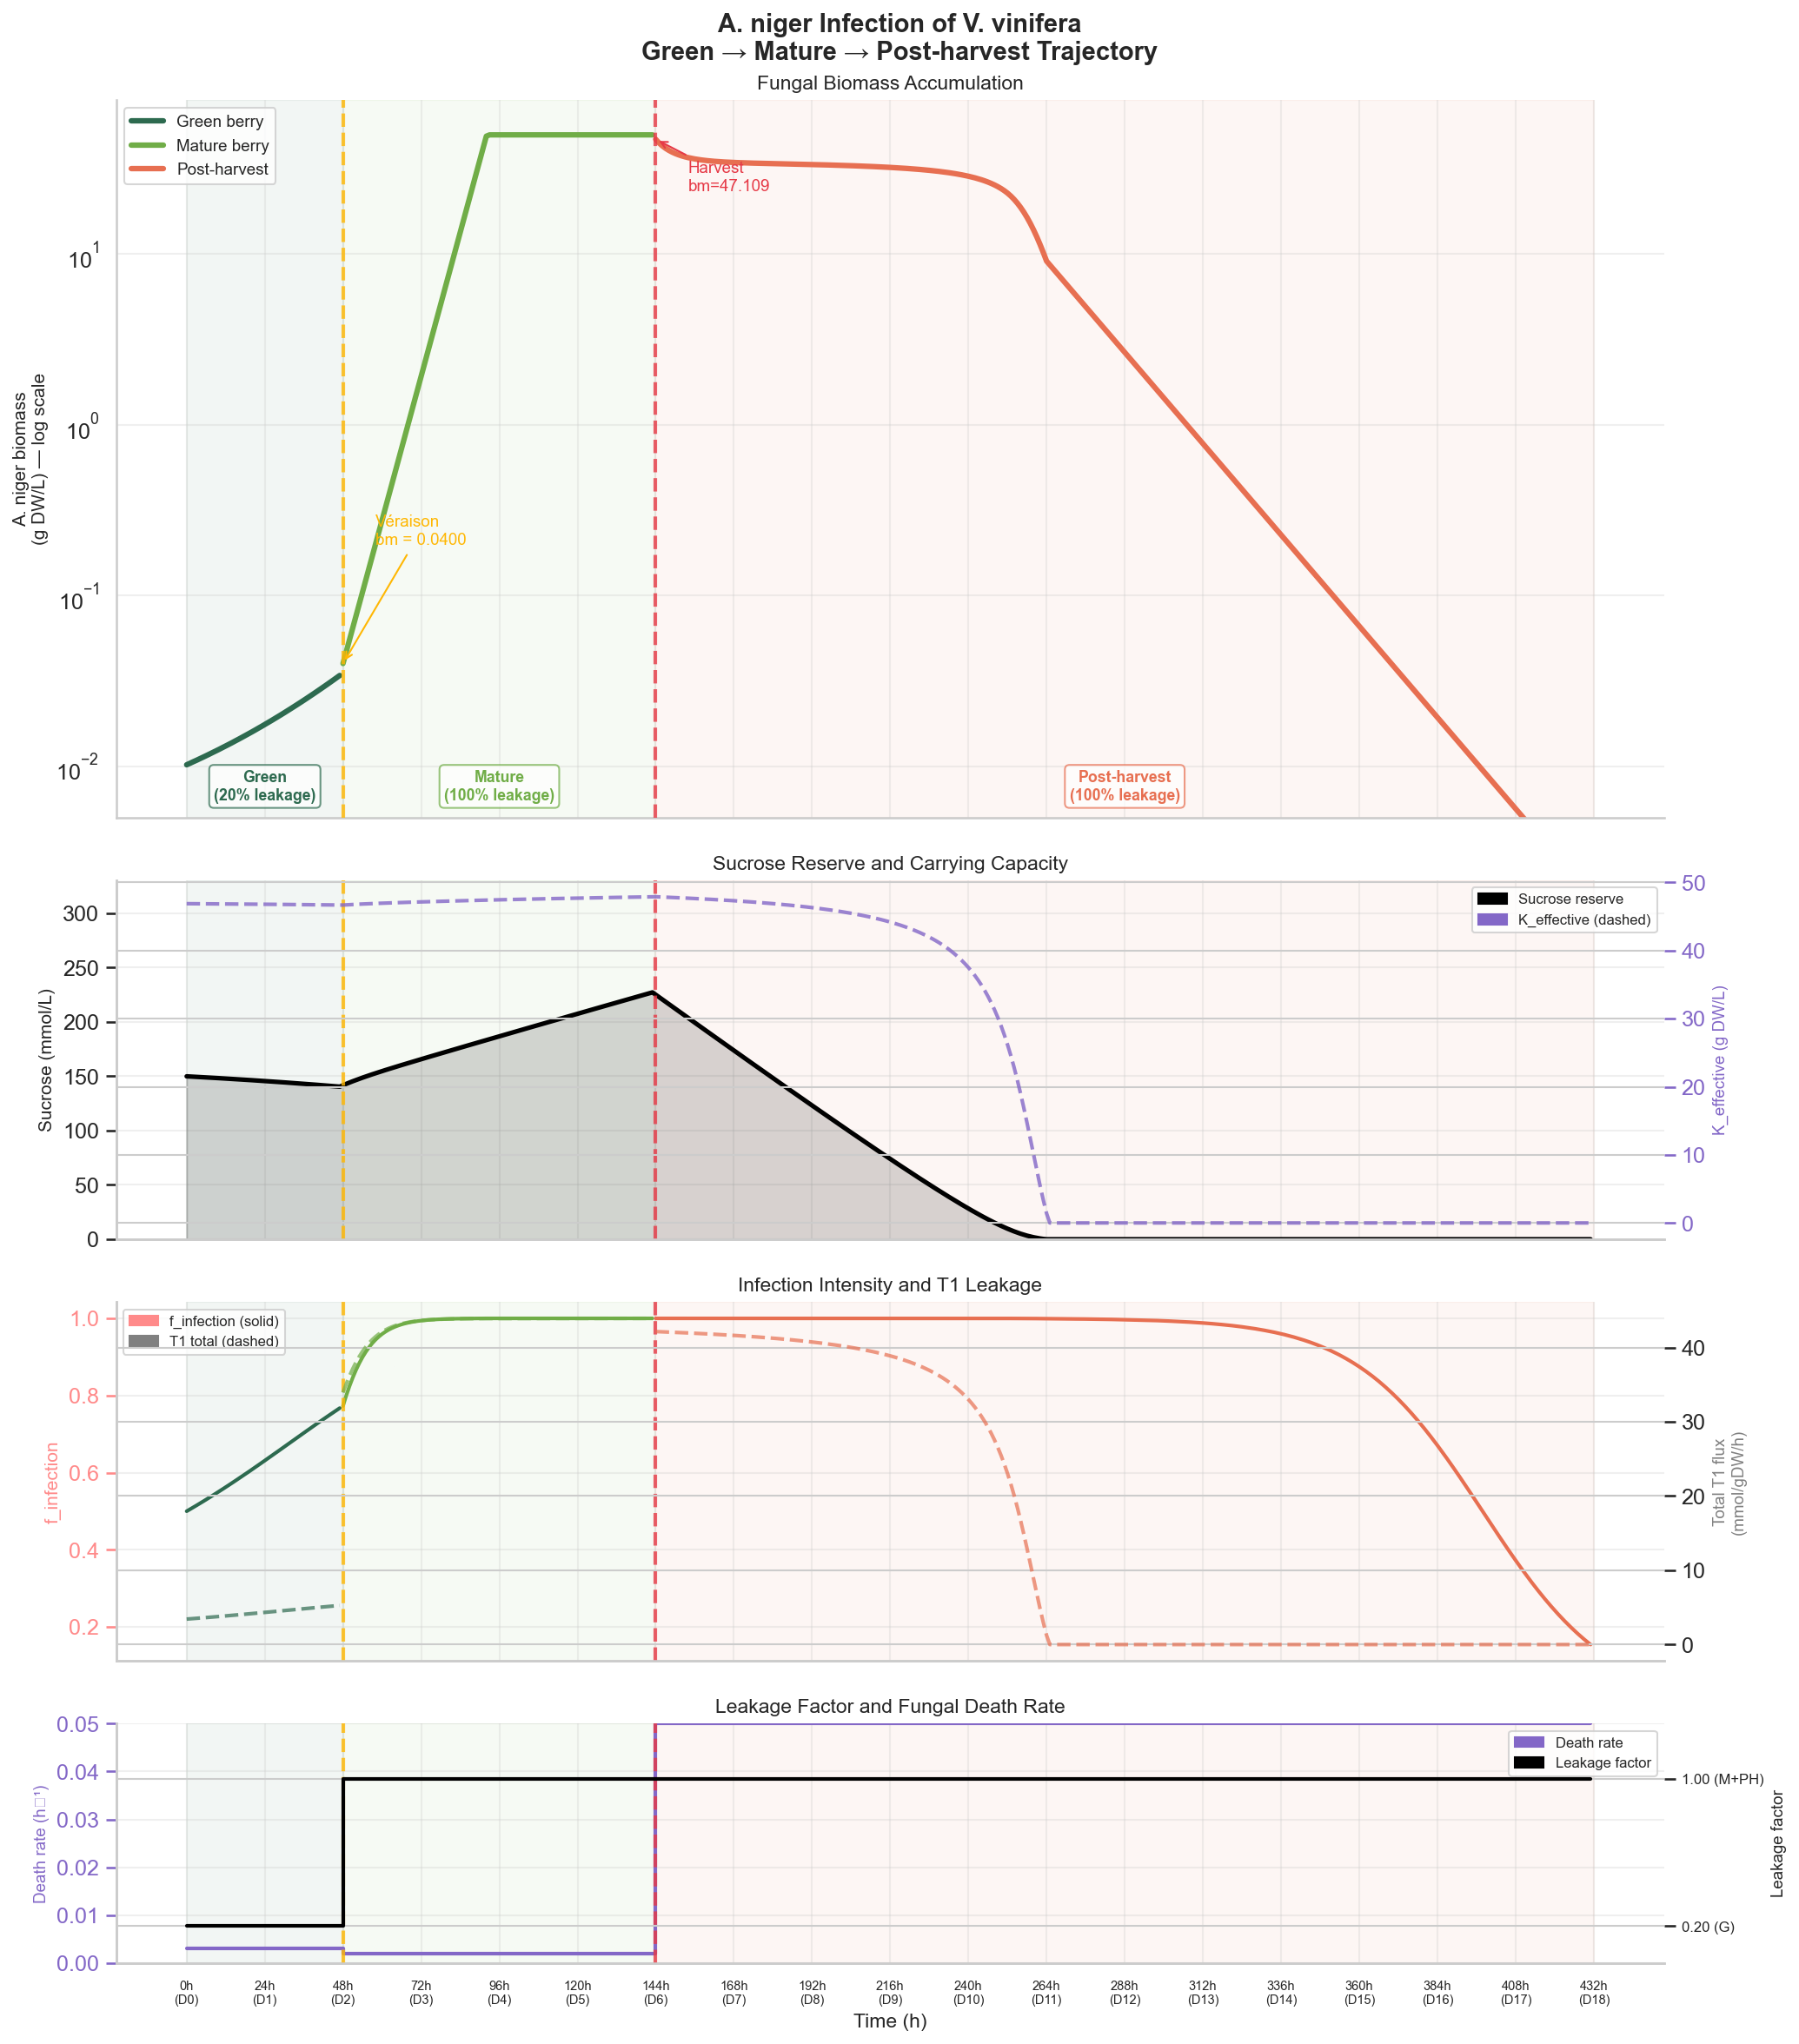

In [ ]:
fig, axes = plt.subplots(4, 1, 
                         figsize     = (14, 16), 
                         sharex      = True,
                         gridspec_kw = {'height_ratios': [3, 1.5, 1.5, 1]})
fig.suptitle('A. niger Infection of V. vinifera\nGreen → Mature → Post-harvest Trajectory',
             fontsize   = 14, 
             fontweight = 'bold', 
             y          = 0.98)

phase_colors = {'green': C_GREEN, 'mature': C_MATURE, 'postharvest': C_HARVEST}
phase_labels = {'green': 'Green berry', 'mature': 'Mature berry', 'postharvest': 'Post-harvest'}

for ax in axes:
    ax.axvspan(0,           T_VERAISON,  alpha = 0.06, color = C_GREEN,   zorder = 0)
    ax.axvspan(T_VERAISON,  T_HARVEST_T, alpha = 0.06, color = C_MATURE,  zorder = 0)
    ax.axvspan(T_HARVEST_T, T_TOTAL,     alpha = 0.06, color = C_HARVEST, zorder = 0)
    ax.axvline(T_VERAISON,  color = C_VERAISON, lw = 2, ls = '--', alpha = 0.8, zorder = 5)
    ax.axvline(T_HARVEST_T, color = C_HARVEST2, lw = 2, ls = '--', alpha = 0.8, zorder = 5)
    ax.grid(alpha = 0.3)

# [0] Biomass
for phase, color in phase_colors.items():
    sub = df_phased[df_phased['phase'] == phase]
    axes[0].plot(sub['time_h'], sub['biomass_an'],
                 color=color, lw=3, label=phase_labels[phase])
axes[0].set_yscale('log')
axes[0].set_ylim(0.005, 80)
axes[0].set_ylabel('A. niger biomass\n(g DW/L) — log scale', fontsize = 10)
axes[0].set_title('Fungal Biomass Accumulation', fontsize = 11)
axes[0].legend(loc = 'upper left', fontsize = 9)

bm_at_v = df_phased.loc[df_phased['time_h'] == T_VERAISON,  'biomass_an'].values
bm_at_h = df_phased.loc[df_phased['time_h'] == T_HARVEST_T, 'biomass_an'].values
if len(bm_at_v):
    axes[0].annotate(f'Véraison\nbm = {bm_at_v[0]:.4f}',
        xy=(T_VERAISON, bm_at_v[0]), xytext = (T_VERAISON+10, bm_at_v[0]*5),
        arrowprops = dict(arrowstyle = '->', color = C_VERAISON), fontsize = 9, color = C_VERAISON)
if len(bm_at_h):
    axes[0].annotate(f'Harvest\nbm={bm_at_h[0]:.3f}',
        xy=(T_HARVEST_T, bm_at_h[0]), xytext = (T_HARVEST_T+10, bm_at_h[0]*0.5),
        arrowprops = dict(arrowstyle = '->', color = C_HARVEST2), fontsize = 9, color = C_HARVEST2)

for t_start, t_end, label, color in [(0,           T_VERAISON,  'Green\n(20% leakage)',        C_GREEN),
                                     (T_VERAISON,  T_HARVEST_T, 'Mature\n(100% leakage)',      C_MATURE),
                                     (T_HARVEST_T, T_TOTAL,     'Post-harvest\n(100% leakage)', C_HARVEST),]:
    axes[0].text((t_start+t_end)/2, 
                 0.02, 
                 label, 
                 ha         = 'center', 
                 va         = 'bottom',
                 fontsize   = 8.5, 
                 color      = color, 
                 fontweight = 'bold',
                 transform  = axes[0].get_xaxis_transform(),
                 bbox       = dict(boxstyle = 'round,pad = 0.3', facecolor = 'white', alpha = 0.7, edgecolor = color))

# [1] Sucrose + K_effective
ax1b = axes[1].twinx()
axes[1].plot(df_phased['time_h'], 
             df_phased['conc_sucrose'],
             color  = 'black', 
             lw     = 2.5, 
             label  = 'Sucrose reserve')
axes[1].fill_between(df_phased['time_h'], 
                     df_phased['conc_sucrose'],
                     alpha = 0.15, 
                     color = 'black')
axes[1].set_ylim(0, SUCROSE_MAX * 1.1)
axes[1].set_ylabel('Sucrose (mmol/L)', fontsize = 10)
axes[1].set_title('Sucrose Reserve and Carrying Capacity', fontsize = 11)

ax1b.plot(df_phased['time_h'], 
          df_phased['K_eff'],
          color = C_FUNGUS, 
          lw    = 2, 
          ls    = '--', 
          alpha = 0.8, 
          label = 'K_effective')
ax1b.set_ylabel('K_effective (g DW/L)', fontsize = 9, color = C_FUNGUS)
ax1b.tick_params(axis = 'y', colors = C_FUNGUS)
l1 = mpatches.Patch(color = 'black',   label = 'Sucrose reserve')
l2 = mpatches.Patch(color = C_FUNGUS,  label = 'K_effective (dashed)')
axes[1].legend(handles = [l1, l2], fontsize = 8, loc = 'upper right')

# [2] f_infection + T1_total
ax2b = axes[2].twinx()
for phase, color in phase_colors.items():
    sub = df_phased[df_phased['phase'] == phase]
    axes[2].plot(sub['time_h'], sub['f_infection'], color = color, lw = 2)
    ax2b.plot(sub['time_h'], sub['T1_total'], color = color, lw = 2, ls = '--', alpha = 0.7)
axes[2].set_ylabel('f_infection', fontsize = 10, color = C_INF)
ax2b.set_ylabel('Total T1 flux\n(mmol/gDW/h)', fontsize = 9, color = 'grey')
axes[2].tick_params(axis='y', colors = C_INF)
axes[2].set_title('Infection Intensity and T1 Leakage', fontsize=11)
l1 = mpatches.Patch(color = C_INF,  label = 'f_infection (solid)')
l2 = mpatches.Patch(color = 'grey', label = 'T1 total (dashed)')
axes[2].legend(handles = [l1, l2], fontsize = 8, loc = 'upper left')

# [3] Leakage + death rate
ax3b = axes[3].twinx()
ax3b.step(df_phased['time_h'], 
          df_phased['leak_factor'],
          color = 'black', 
          lw    = 2, 
          where = 'post')
ax3b.set_ylim(0, 1.3)
ax3b.set_ylabel('Leakage factor', fontsize = 9)
ax3b.set_yticks([0.20, 1.00])
ax3b.set_yticklabels(['0.20 (G)', '1.00 (M+PH)'], fontsize = 8)

axes[3].step(df_phased['time_h'], 
             df_phased['death_rate'],
             color = C_FUNGUS, 
             lw    = 2, 
             where = 'post')
axes[3].set_ylim(0, 0.05)
axes[3].set_ylabel('Death rate (h⁻¹)', fontsize = 9, color = C_FUNGUS)
axes[3].tick_params(axis = 'y', colors = C_FUNGUS)
axes[3].set_title('Leakage Factor and Fungal Death Rate', fontsize = 11)
l1 = mpatches.Patch(color = C_FUNGUS, label = 'Death rate')
l2 = mpatches.Patch(color = 'black',  label = 'Leakage factor')
axes[3].legend(handles=[l1, l2], fontsize = 8, loc = 'upper right')

axes[3].set_xlabel('Time (h)', fontsize = 11)
day_ticks = np.arange(0, T_TOTAL+1, 24)
axes[3].set_xticks(day_ticks)
axes[3].set_xticklabels([f'{int(t)}h\n(D{int(t//24)})' for t in day_ticks], fontsize = 7)

plt.tight_layout()
# plt.savefig('fig1_full_trajectory.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 5. Key Results

Summary statistics for each phase of the infection trajectory. Reported values are computed from the `df_phased` DataFrame produced by `run_phased_dfba`.

**Reading the output:**
- `bm_an start/end` — fungal biomass at the first and last timestep of the phase
- `Δbm_an` — net biomass change; negative in post-harvest = collapse phase
- `f_infection end` — infection intensity at phase end ($0 =$ no infection, $1 =$ complete host suppression)
- `T1_total avg` — mean total leakage flux across all interface metabolites during the phase
- `Sucrose half-life` — time at which sucrose reserve falls to 50% of initial value (post-harvest only)

In [11]:
print('PHASED INFECTION TRAJECTORY — KEY RESULTS')
print('_'*55)

for phase, color in [('green','Green'), ('mature','Mature'), ('postharvest','Post-harvest')]:
    sub = df_phased[df_phased['phase'] == phase]
    duration = sub['time_h'].iloc[-1] - sub['time_h'].iloc[0] + 1.0
    print(f'\n{color} phase:')
    
    print(f'  Duration          : {duration:.0f}h')
    print(f'  bm_an start       : {sub["biomass_an"].iloc[0]:.5f} gDW/L')
    print(f'  bm_an end         : {sub["biomass_an"].iloc[-1]:.5f} gDW/L')
    print(f'  Δbm_an            : {sub["biomass_an"].iloc[-1]-sub["biomass_an"].iloc[0]:.5f} gDW/L')
    print(f'  f_infection end   : {sub["f_infection"].iloc[-1]:.4f}')
    print(f'  T1_total avg      : {sub["T1_total"].mean():.3f} mmol/gDW/h')

print(f'\nOverall peak: {df_phased["biomass_an"].max():.3f} gDW/L at t = {df_phased.loc[df_phased["biomass_an"].idxmax(),"time_h"]:.0f}h')

t_half_suc = df_phased[(df_phased['phase'] == 'postharvest') &
                        (df_phased['conc_sucrose'] <= SUCROSE_INIT/2)]['time_h'].min()
print(f'Sucrose half-life   : t = {t_half_suc:.0f}h (D{t_half_suc/24:.1f})')

PHASED INFECTION TRAJECTORY — KEY RESULTS
_______________________________________________________

Green phase:
  Duration          : 48h
  bm_an start       : 0.01020 gDW/L
  bm_an end         : 0.03403 gDW/L
  Δbm_an            : 0.02383 gDW/L
  f_infection end   : 0.7673
  T1_total avg      : 4.326 mmol/gDW/h

Mature phase:
  Duration          : 96h
  bm_an start       : 0.03996 gDW/L
  bm_an end         : 50.00000 gDW/L
  Δbm_an            : 49.96004 gDW/L
  f_infection end   : 0.9998
  T1_total avg      : 43.125 mmol/gDW/h

Post-harvest phase:
  Duration          : 288h
  bm_an start       : 47.10855 gDW/L
  bm_an end         : 0.00173 gDW/L
  Δbm_an            : -47.10682 gDW/L
  f_infection end   : 0.1544
  T1_total avg      : 15.111 mmol/gDW/h

Overall peak: 50.000 gDW/L at t = 93h
Sucrose half-life   : t = 216h (D9.0)


## 6. Conclusion

### 6.1 Infection Trajectory Summary

The phased dFBA simulation recapitulates the full *A. niger* infection of *V. vinifera* across three biologically distinct stages:

**Green phase (0–48 h):** Fungal biomass grows slowly ($0.010 \to 0.034\ g\,DW/L$) under restricted cell wall access ($20\%$ leakage). Infection intensity rises from $0.50$ to $0.77$, reflecting progressive but limited cytoplasmic access. The dominant interface metabolites are glutamate and proline — the metabolic signature of *pre-véraison* amino acid catabolism.

**Mature phase (48–144 h):** The *véraison* transition triggers an explosive shift. Full leakage ($100\%$) combined with the mature berry's high-flux TCA metabolism (citrate proxy: $19.37\ mmol/gDW/h$) enables rapid fungal growth to carrying capacity ($K = 50\ g\,DW/L$) within $\sim45\ h$ of *véraison*. Infection intensity reaches $\approx 1.0$. This phase confirms *véraison* as the critical window of maximum infection susceptibility — consistent with the blocked stilbene defence identified in Phase 1C and Phase 3B.

**Post-harvest phase (144–432 h):** Without phloem replenishment, sucrose depletes (half-life $t \approx 216\ h$, Day 9). As glucose/fructose leakage falls with the Michaelis–Menten sucrose factor, T1 flux collapses and the fungus enters net decline driven by the post-harvest death rate ($d = 0.05\ h^{-1}$). Biomass falls from peak $\approx 50\ g\,DW/L$ to near-zero by Day 18.

### 6.2 Biological Interpretation

The simulation identifies two decisive transitions:

1. **Véraison** — the switch from $20\%$ to $100\%$ leakage amplifies T1 flux by $5\times$ and triggers exponential fungal growth. This is the intervention window with the highest potential impact for biocontrol.
2. **Sucrose exhaustion** — the post-harvest collapse is driven by resource depletion, not active host defence. Once sucrose is gone, the infection is self-limiting.

### 6.3 Limitations

- **Leakage factors (20%, 100%, 100%) are phenomenological** — not derived from experimental membrane permeability measurements. They represent qualitative assumptions about cell wall accessibility at each stage.
- **FBAs are decoupled per timestep** — host and pathogen are optimised independently; competition for shared resources is not resolved jointly.
- **Death rates are not experimentally grounded** — particularly the post-harvest value ($0.05\ h^{-1}$) which dominates the collapse dynamics.
- **Single initial inoculum** — the model assumes a single infection event at $t = 0$; secondary inoculation events and sporulation are not modelled.
- **Sucrose dynamics are simplified** — inflow/use rates are constant per phase; actual phloem loading is temperature- and turgor-dependent.

## 7. References

* **iJB1325** (Brandl et al., 2018)

Brandl, J., Aguilar-Pontes, M. V., Schäpe, P., Nørregaard, A., Arvas, M., Ram, A. F. J., Meyer, V., Tsang, A., de Vries, R. P., & Andersen, M. R. (2018). A community-driven reconstruction of the *Aspergillus niger* metabolic network. *Fungal Biology and Biotechnology*, *5*, 16. https://doi.org/10.1186/s40694-018-0060-7

* **iMS7199** (Sampaio, M., Rocha, M., & Dias, O., 2024)

Sampaio, M., Rocha, M., & Dias, O. (2024). iMS7199 – genome-scale metabolic model of *Vitis vinifera* (Model ID MODEL2408120001). [Data set]. BioModels. https://biomodels.org/MODEL2408120001